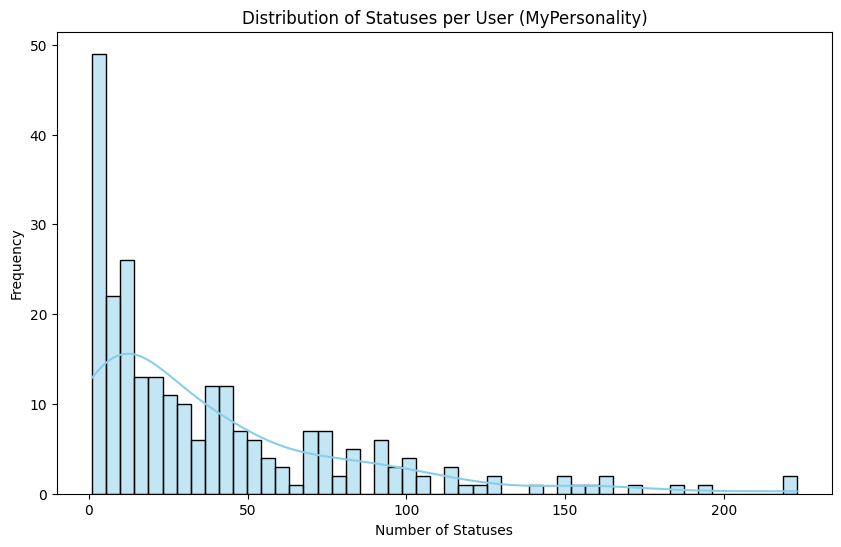

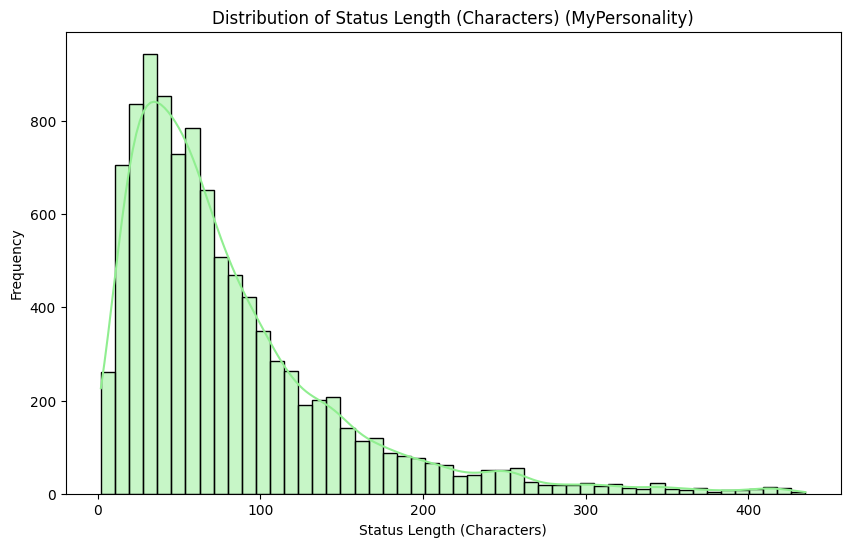

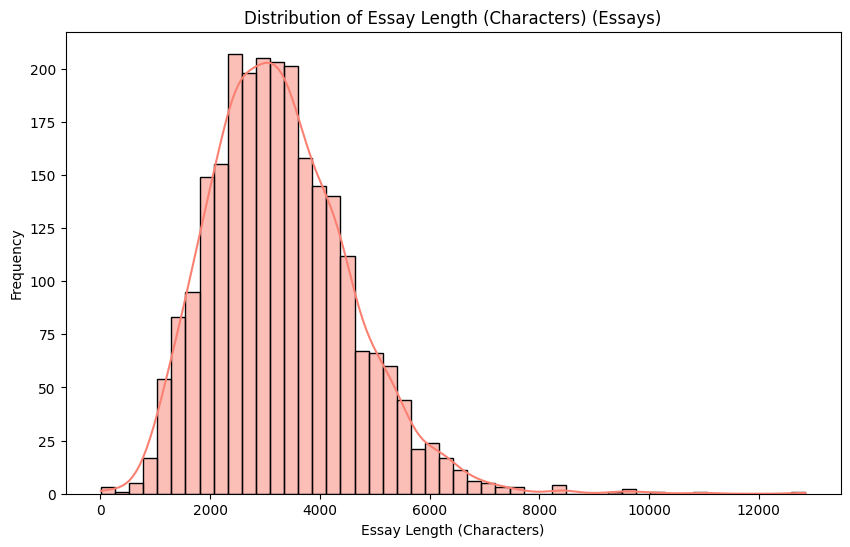

--- MyPersonality Dataset Summary ---
Total Unique Users: 250
Total Statuses: 9917
Average Statuses per User: 39.67
Min Statuses per User: 1
Max Statuses per User: 223
Average Status Length: 80.65 characters
Min Status Length: 2 characters
Max Status Length: 435 characters

--- Essays Dataset Summary ---
Total Unique Users: 2468
Total Essays: 2468
Average Essay Length: 3294.95 characters
Min Essay Length: 7 characters
Max Essay Length: 12852 characters


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load Data
df_essays = pd.read_csv('wcpr_essays.csv', encoding='cp1252')
df_mypersonality = pd.read_csv('wcpr_mypersonality.csv', encoding='cp1252')

# --- MyPersonality Dataset EDA ---

# Calculate Number of Statuses per User
status_counts = df_mypersonality.groupby('#AUTHID').size()

# Plot: Distribution of Statuses per User
plt.figure(figsize=(10, 6))
sns.histplot(status_counts, bins=50, kde=True, color='skyblue')
plt.title('Distribution of Statuses per User (MyPersonality)')
plt.xlabel('Number of Statuses')
plt.ylabel('Frequency')
plt.show()

# Calculate Status Lengths
df_mypersonality['STATUS_LEN'] = df_mypersonality['STATUS'].astype(str).apply(len)

# Plot: Distribution of Status Lengths
plt.figure(figsize=(10, 6))
sns.histplot(df_mypersonality['STATUS_LEN'], bins=50, kde=True, color='lightgreen')
plt.title('Distribution of Status Length (Characters) (MyPersonality)')
plt.xlabel('Status Length (Characters)')
plt.ylabel('Frequency')
plt.show()

# --- Essays Dataset EDA ---

# Calculate Essay Lengths
df_essays['TEXT_LEN'] = df_essays['TEXT'].astype(str).apply(len)

# Plot: Distribution of Essay Lengths
plt.figure(figsize=(10, 6))
sns.histplot(df_essays['TEXT_LEN'], bins=50, kde=True, color='salmon')
plt.title('Distribution of Essay Length (Characters) (Essays)')
plt.xlabel('Essay Length (Characters)')
plt.ylabel('Frequency')
plt.show()

# --- Print Summary Statistics ---
print("--- MyPersonality Dataset Summary ---")
print(f"Total Unique Users: {df_mypersonality['#AUTHID'].nunique()}")
print(f"Total Statuses: {len(df_mypersonality)}")

print(f"Average Statuses per User: {status_counts.mean():.2f}")
print(f"Min Statuses per User: {status_counts.min()}")
print(f"Max Statuses per User: {status_counts.max()}")

print(f"Average Status Length: {df_mypersonality['STATUS_LEN'].mean():.2f} characters")
print(f"Min Status Length: {df_mypersonality['STATUS_LEN'].min()} characters")
print(f"Max Status Length: {df_mypersonality['STATUS_LEN'].max()} characters\n")


print("--- Essays Dataset Summary ---")
print(f"Total Unique Users: {df_essays['#AUTHID'].nunique()}")
print(f"Total Essays: {len(df_essays)}")

print(f"Average Essay Length: {df_essays['TEXT_LEN'].mean():.2f} characters")
print(f"Min Essay Length: {df_essays['TEXT_LEN'].min()} characters")
print(f"Max Essay Length: {df_essays['TEXT_LEN'].max()} characters")

In [10]:
print("min, median, mean, max:", status_counts.min(), status_counts.median(), status_counts.mean(), status_counts.max())

# 2) tính percentiles phổ biến
p90 = int(np.percentile(status_counts, 90))
p95 = int(np.percentile(status_counts, 95))
p99 = int(np.percentile(status_counts, 99))
print("90th, 95th, 99th percentiles:", p90, p95, p99)

min, median, mean, max: 1 25.0 39.668 223
90th, 95th, 99th percentiles: 98 126 189


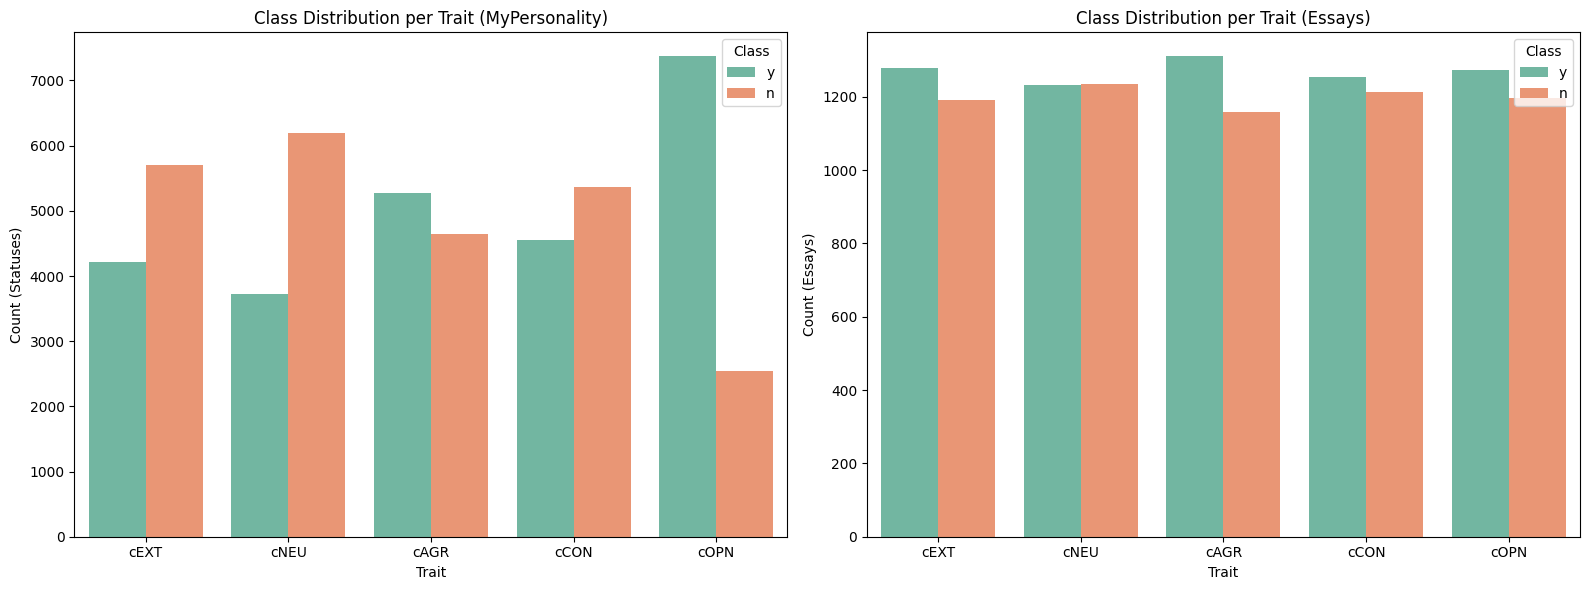

--- MyPersonality Dataset: Class Distributions ---
cEXT: {'n': 5707, 'y': 4210}
cNEU: {'n': 6200, 'y': 3717}
cAGR: {'y': 5268, 'n': 4649}
cCON: {'n': 5361, 'y': 4556}
cOPN: {'y': 7370, 'n': 2547}

--- Essays Dataset: Class Distributions ---
cEXT: {'y': 1277, 'n': 1191}
cNEU: {'n': 1235, 'y': 1233}
cAGR: {'y': 1310, 'n': 1158}
cCON: {'y': 1254, 'n': 1214}
cOPN: {'y': 1272, 'n': 1196}


In [11]:
# Define the personality trait columns
traits = ["cEXT", "cNEU", "cAGR", "cCON", "cOPN"]

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: MyPersonality Dataset ---
# Melt the dataframe to group all traits into two columns: 'Trait' and 'Class'
df_my_melted = df_mypersonality.melt(value_vars=traits, var_name='Trait', value_name='Class')

# Create the countplot
sns.countplot(data=df_my_melted, x='Trait', hue='Class', ax=axes[0], palette='Set2', hue_order=['y', 'n'])
axes[0].set_title('Class Distribution per Trait (MyPersonality)')
axes[0].set_ylabel('Count (Statuses)')

# --- Plot 2: Essays Dataset ---
# Melt the dataframe
df_essays_melted = df_essays.melt(value_vars=traits, var_name='Trait', value_name='Class')

# Create the countplot
sns.countplot(data=df_essays_melted, x='Trait', hue='Class', ax=axes[1], palette='Set2', hue_order=['y', 'n'])
axes[1].set_title('Class Distribution per Trait (Essays)')
axes[1].set_ylabel('Count (Essays)')

plt.tight_layout()
plt.show()

# --- Print Exact Distributions ---
print("--- MyPersonality Dataset: Class Distributions ---")
for trait in traits:
    counts = df_mypersonality[trait].value_counts().to_dict()
    print(f"{trait}: {counts}")

print("\n--- Essays Dataset: Class Distributions ---")
for trait in traits:
    counts = df_essays[trait].value_counts().to_dict()
    print(f"{trait}: {counts}")